# Handle Class Imbalance — Oversampling (SMOTE) vs Adjusted Model

**Skenario 1 — Oversampling.** Kelas minoritas (A, B) digandakan secara sintetis pakai **SMOTE** sampai seimbang dengan kelas mayoritas (E). SMOTE hanya dijalankan pada **fold training** lewat `imblearn.Pipeline` supaya fold validasi tetap distribusi asli (anti-bocor).

Dataset `Dataset_TehHijau.csv` **ber-grup**: 10.409 baris tapi hanya 274 `Sampling_ID` (≈38 pembacaan sensor mirip per sampel). Maka CV memakai `StratifiedKFold(groups=Sampling_ID)` agar pembacaan sampel yang sama tak bocor ke train+val. Metrik andalan untuk imbalance: **balanced accuracy** & **macro-F1** (bukan accuracy).

> ⚠️ **Catatan runtime:** oversampling membesarkan training set (~5×4649 ≈ 23k baris/fold). SVC (`probability=True`) jadi **sangat lambat** O(N²). Kalau hanya butuh sebagian model, komentari entri yang tak perlu di `MODELS`.

In [1]:
!python -m pip install -q numpy pandas scikit-learn imbalanced-learn \
    xgboost catboost matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys, os
import warnings
warnings.filterwarnings('ignore')

cwd = os.path.abspath(os.getcwd())
project_root = cwd.split('codes')[0] + 'codes'
sys.path.append(os.path.abspath(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

In [3]:
import importlib

def reload_package(package_name):
    for name in sorted([n for n in sys.modules if n.startswith(package_name)], reverse=True):
        importlib.reload(sys.modules[name])

reload_package('utils')

## 1. Konfigurasi

In [4]:
from imblearn.over_sampling import SMOTE  # noqa
from imblearn.under_sampling import RandomUnderSampler  # noqa
from imblearn.combine import SMOTEENN  # noqa
from imblearn.over_sampling import SMOTE
from utils.imbalance_eval import evaluate_cv, BEST_PARAMS, MODEL_ORDER

dataset_path = os.path.join(project_root, 'dataset', 'Dataset_TehHijau.csv')

feature_cols = [
    'MQ3', 'TGS822', 'TGS2602', 'MQ5', 'MQ138', 'TGS2620',
    'TGS813', 'TGS2600', 'TGS2611', 'TGS2603', 'Humidity', 'Celsius',
]
target_col = 'Kategori'
group_col  = 'Sampling_ID'   # grup anti-bocor (lihat memory grouped-data-leakage)

# Resampler skenario ini (dipakai HANYA pada fold training oleh evaluate_cv)
RESAMPLER = SMOTE(random_state=42, k_neighbors=5)
STRATEGY  = 'oversampling'

# Backend hardware — samakan dengan notebook 3.4.2 (GPU). Ganti ke
# 'cpu'/'CPU' kalau tidak ada GPU.
XGB_DEVICE   = 'cuda'
CAT_TASK_TYPE = 'GPU'

# Model yang dibandingkan (komentari yang tak perlu untuk menghemat waktu)
MODELS = list(MODEL_ORDER)
print('Models:', MODELS)

# Hasil disimpan relatif terhadap folder notebook ini
OUT_DIR = os.path.join(cwd, 'results', STRATEGY)
os.makedirs(OUT_DIR, exist_ok=True)
print('Output:', OUT_DIR)

Models: ['SVC Linear', 'SVC Sigmoid', 'SVC Poly', 'SVC RBF', 'XGBoost GBTree', 'XGBoost Dart', 'CatBoost']
Output: c:\`Bioinformatics\quantum-gesang\codes\notebooks\handle_imbalance\results\oversampling


## 2. Muat Data & Distribusi Kelas

In [5]:
data = pd.read_csv(dataset_path)
print('shape:', data.shape, '| n Sampling_ID:', data[group_col].nunique())
data.head()

shape: (10409, 130) | n Sampling_ID: 274


,MQ3,TGS822,TGS2602,MQ5,MQ138,TGS2620,TGS813,TGS2600,TGS2611,TGS2603,Humidity,Celsius,Chop_ID,Sampling_ID,Aroma,Taste,Color,Appearance,Dreg,Kategori,Standar Kualitas,MQ3_mean,MQ3_min,MQ3_max,MQ3_std,MQ3_skew,MQ3_kurtosis,MQ3_auc,TGS822_mean,TGS822_min,TGS822_max,TGS822_std,TGS822_skew,TGS822_kurtosis,TGS822_auc,TGS2602_mean,TGS2602_min,TGS2602_max,TGS2602_std,TGS2602_skew,TGS2602_kurtosis,TGS2602_auc,MQ5_mean,MQ5_min,MQ5_max,MQ5_std,MQ5_skew,MQ5_kurtosis,MQ5_auc,MQ138_mean,MQ138_min,MQ138_max,MQ138_std,MQ138_skew,MQ138_kurtosis,MQ138_auc,TGS2620_mean,TGS2620_min,TGS2620_max,TGS2620_std,TGS2620_skew,TGS2620_kurtosis,TGS2620_auc,TGS813_mean,TGS813_min,TGS813_max,TGS813_std,TGS813_skew,TGS813_kurtosis,TGS813_auc,TGS2600_mean,TGS2600_min,TGS2600_max,TGS2600_std,TGS2600_skew,TGS2600_kurtosis,TGS2600_auc,TGS2611_mean,TGS2611_min,TGS2611_max,TGS2611_std,TGS2611_skew,TGS2611_kurtosis,TGS2611_auc,TGS2603_mean,TGS2603_min,TGS2603_max,TGS2603_std,TGS2603_skew,TGS2603_kurtosis,TGS2603_auc,Humidity_mean,Humidity_min,Humidity_max,Humidity_std,Humidity_skew,Humidity_kurtosis,Humidity_auc,Celsius_mean,Celsius_min,Celsius_max,Celsius_std,Celsius_skew,Celsius_kurtosis,Celsius_auc,Aroma_mean,Aroma_min,Aroma_max,Aroma_std,Aroma_auc,Taste_mean,Taste_min,Taste_max,Taste_std,Taste_auc,Color_mean,Color_min,Color_max,Color_std,Color_auc,Appearance_mean,Appearance_min,Appearance_max,Appearance_std,Appearance_auc,Dreg_mean,Dreg_min,Dreg_max,Dreg_std,Dreg_auc
0,90.0000,43.0000,46.0000,133.0000,97.0000,46.0000,552.0000,289.0000,546.0000,371.0000,46.4000,38.9000,TR612,TR612_1,2.9000,36,3.2000,2.8000,3.2000,D,Baik,89.7000,89.0000,90,0.4830,-0.8729,-1.2381,807.0000,41.9000,41,43,0.7379,0.1399,-0.9604,377.0000,46.8000,46,48,0.7888,0.3436,-1.1531,421.0000,132.5000,132,133.0000,0.5270,0.0000,-2.0000,1192.5000,96.1000,95,97,0.7379,-0.1399,-0.9604,865.0000,45.7000,45,47,0.6749,0.3657,-0.7055,411.0000,551.6000,550,553,0.8433,-0.3281,-0.3359,4964.5000,289.8000,289.0000,291,0.7888,0.3436,-1.1531,2609.0000,546.5000,545,548,0.8498,0.0000,-0.4852,4918.5000,370.2000,369,371,0.7888,-0.3436,-1.1531,3331.0000,46.4300,46.3000,46.5000,0.0675,-0.3657,-0.7055,417.9500,38.8100,38.7000,38.9000,0.0876,-0.1884,-1.5261,349.3000,2.9000,2.9000,2.9000,0.0000,26.1000,36,36,36,0,324,3.2000,3.2000,3.2000,0.0000,28.8000,2.8000,2.8000,2.8000,0.0000,25.2000,3.2000,3.2000,3.2000,0.0000,28.8000
1,90.0000,42.0000,47.0000,133.0000,96.0000,47.0000,551.0000,290.0000,547.0000,371.0000,46.5000,38.9000,TR612,TR612_1,2.9000,36,3.2000,2.8000,3.2000,D,Baik,89.7000,89.0000,90,0.4830,-0.8729,-1.2381,807.0000,41.9000,41,43,0.7379,0.1399,-0.9604,377.0000,46.8000,46,48,0.7888,0.3436,-1.1531,421.0000,132.5000,132,133.0000,0.5270,0.0000,-2.0000,1192.5000,96.1000,95,97,0.7379,-0.1399,-0.9604,865.0000,45.7000,45,47,0.6749,0.3657,-0.7055,411.0000,551.6000,550,553,0.8433,-0.3281,-0.3359,4964.5000,289.8000,289.0000,291,0.7888,0.3436,-1.1531,2609.0000,546.5000,545,548,0.8498,0.0000,-0.4852,4918.5000,370.2000,369,371,0.7888,-0.3436,-1.1531,3331.0000,46.4300,46.3000,46.5000,0.0675,-0.3657,-0.7055,417.9500,38.8100,38.7000,38.9000,0.0876,-0.1884,-1.5261,349.3000,2.9000,2.9000,2.9000,0.0000,26.1000,36,36,36,0,324,3.2000,3.2000,3.2000,0.0000,28.8000,2.8000,2.8000,2.8000,0.0000,25.2000,3.2000,3.2000,3.2000,0.0000,28.8000
2,89.0000,42.0000,47.0000,133.0000,97.0000,45.0000,553.0000,291.0000,547.0000,369.0000,46.4000,38.9000,TR612,TR612_1,2.9000,36,3.2000,2.8000,3.2000,D,Baik,89.7000,89.0000,90,0.4830,-0.8729,-1.2381,807.0000,41.9000,41,43,0.7379,0.1399,-0.9604,377.0000,46.8000,46,48,0.7888,0.3436,-1.1531,421.0000,132.5000,132,133.0000,0.5270,0.0000,-2.0000,1192.5000,96.1000,95,97,0.7379,-0.1399,-0.9604,865.0000,45.7000,45,47,0.6749,0.3657,-0.7055,411.0000,551.6000,550,553,0.8433,-0.3281,-0.3359,4964.5000,289.8000,289.0000,291,0.7888,0.3436,-1.1531,2609.0000,546.5000,545,548,0.8498,0.0000,-0.4852,4918.5000,370.2000,369,371,0.7888,-0.3436,-1.1531,3331.0000,46.4300,46.3000,46.5000,0.0675,-0.3657,-0.7055,417.9500,38.8100,38.700

Distribusi kelas (baris):
Kategori
A     927
B     229
C    2287
D    2317
E    4649
Name: count, dtype: int64

Rasio imbalance (maks/min): 20.3x


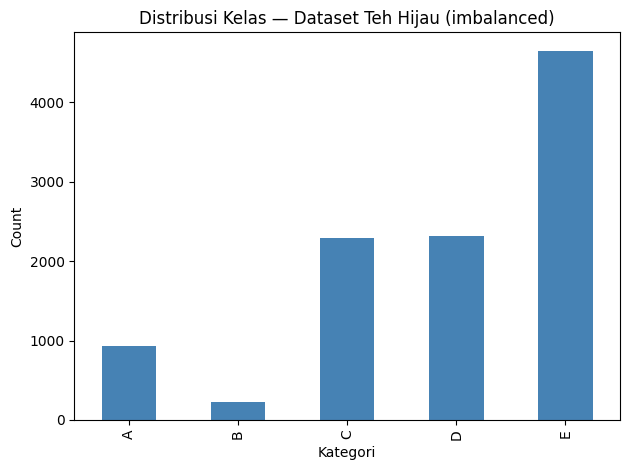

In [6]:
dist = data[target_col].value_counts().sort_index()
print('Distribusi kelas (baris):')
print(dist)
print('\nRasio imbalance (maks/min): {:.1f}x'.format(dist.max() / dist.min()))

ax = dist.plot(kind='bar', color='steelblue')
ax.set_xlabel('Kategori'); ax.set_ylabel('Count')
ax.set_title('Distribusi Kelas — Dataset Teh Hijau (imbalanced)')
plt.tight_layout(); plt.show()

In [7]:
from sklearn.preprocessing import LabelEncoder

X = data[feature_cols]
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(data[target_col])
groups = data[group_col].values
labels = np.unique(y)
class_names = list(label_encoder.classes_)
print('X:', X.shape, '| classes:', class_names)

X: (10409, 12) | classes: ['A', 'B', 'C', 'D', 'E']


## 3. PCA — jumlah komponen optimal (95% varians)

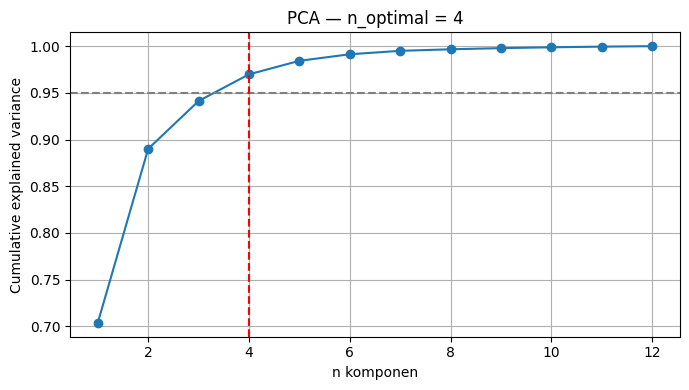

n_optimal = 4


In [8]:
from sklearn.decomposition import PCA

_pca = PCA(n_components=X.shape[1]).fit(X)
cumvar = np.cumsum(_pca.explained_variance_ratio_)
n_optimal = int(np.argmax(cumvar >= 0.95) + 1)

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cumvar) + 1), cumvar, marker='o')
plt.axhline(0.95, color='gray', ls='--')
plt.axvline(n_optimal, color='red', ls='--')
plt.xlabel('n komponen'); plt.ylabel('Cumulative explained variance')
plt.title(f'PCA — n_optimal = {n_optimal}'); plt.grid(True); plt.tight_layout(); plt.show()
print('n_optimal =', n_optimal)

## 4. Komposisi Dataset — Sebelum vs Sesudah Sampling

Resampling (`SMOTE(random_state=42, k_neighbors=5)`) dijalankan pada **1 fold training** (persis seperti yang terjadi di CV: fit `StandardScaler`+`PCA` pada fold train, lalu resample di ruang PCA).

- **Kiri (histogram):** jumlah baris per kelas sebelum vs sesudah. Ini **tidak** terpengaruh PCA — label kelas tetap utuh, PCA hanya mengubah fitur.
- **Tengah & kanan (scatter PC1–PC2):** sebaran fitur di ruang PCA sebelum vs sesudah; di sinilah efek PCA terlihat — titik sintetis (SMOTE) muncul di antara titik minoritas nyata.

Ditampilkan untuk 1 fold sebagai ilustrasi; tiap fold di CV diresample dengan cara sama. Fold **validasi tidak diresample**.

Komposisi kelas pada 1 fold training (strategi=oversampling):
   Sebelum  Sesudah  Delta
A      742     3719   2977
B      183     3719   3536
C     1830     3719   1889
D     1853     3719   1866
E     3719     3719      0


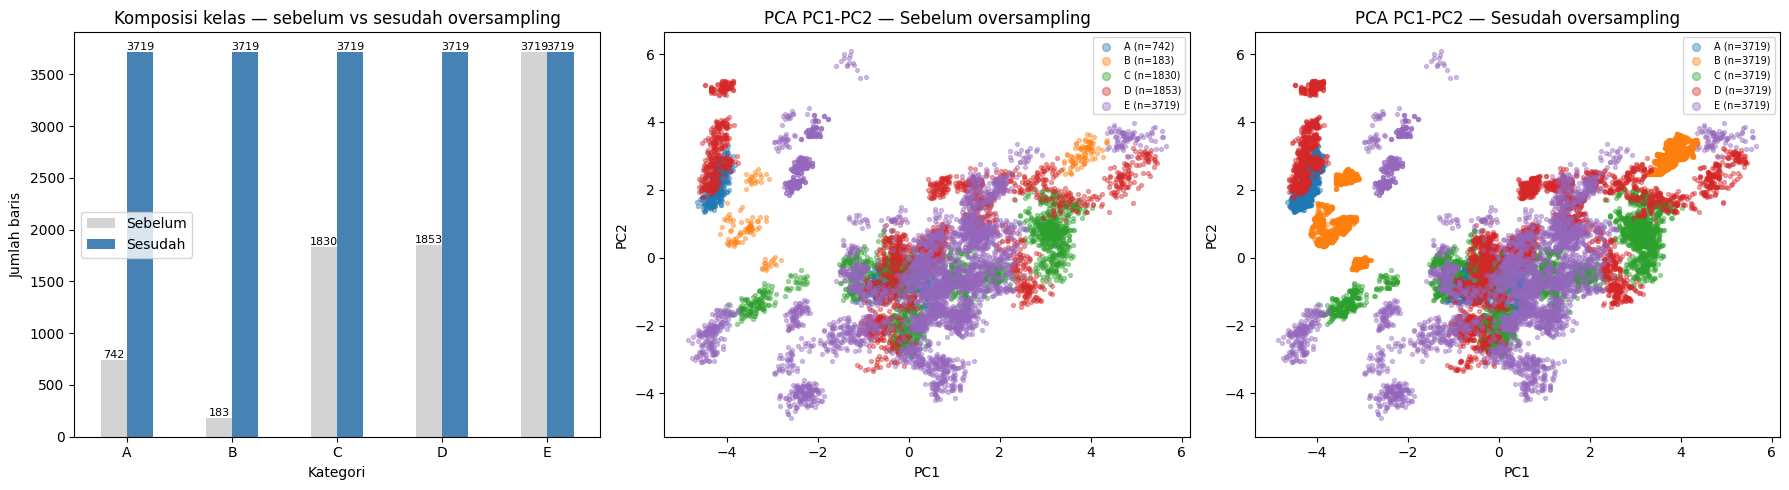

In [9]:
from collections import Counter
from utils.imbalance_eval import resample_for_viz

viz = resample_for_viz(X, y, groups, RESAMPLER, n_optimal, fold_index=0)
cb, ca = Counter(viz['y_before']), Counter(viz['y_after'])
comp = pd.DataFrame(
    {'Sebelum': [cb.get(i, 0) for i in labels],
     'Sesudah': [ca.get(i, 0) for i in labels]}, index=class_names)
comp['Delta'] = comp['Sesudah'] - comp['Sebelum']
print(f'Komposisi kelas pada 1 fold training (strategi={STRATEGY}):')
print(comp)
comp.to_csv(os.path.join(OUT_DIR, f'{STRATEGY}_composition.csv'))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) histogram jumlah kelas sebelum vs sesudah
comp[['Sebelum', 'Sesudah']].plot(
    kind='bar', ax=axes[0], color={'Sebelum': 'lightgray', 'Sesudah': 'steelblue'})
axes[0].set_title(f'Komposisi kelas — sebelum vs sesudah {STRATEGY}')
axes[0].set_xlabel('Kategori'); axes[0].set_ylabel('Jumlah baris')
axes[0].tick_params(axis='x', rotation=0)
for c in axes[0].containers:
    axes[0].bar_label(c, fontsize=8)

# (b)(c) scatter PCA PC1-PC2 sebelum vs sesudah
cmap = plt.cm.tab10
for ax, (Xp, yp, ttl) in zip(axes[1:], [
        (viz['X_before'], viz['y_before'], 'Sebelum'),
        (viz['X_after'],  viz['y_after'],  'Sesudah')]):
    for i, cn in enumerate(class_names):
        m = yp == labels[i]
        ax.scatter(Xp[m, 0], Xp[m, 1], s=8, alpha=0.4,
                   color=cmap(i), label=f'{cn} (n={int(m.sum())})')
    ax.set_title(f'PCA PC1-PC2 — {ttl} {STRATEGY}')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.legend(fontsize=7, markerscale=2)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, f'{STRATEGY}_composition_before_after.png'),
            dpi=130, bbox_inches='tight')
plt.show()

## 5. Evaluasi: Resampling vs Adjusted Model

Untuk tiap model dijalankan **dua kondisi** dengan split & params identik:

- **adjusted** — tanpa resampling, classifier pakai bobot kelas `balanced` (seperti notebook 3.4.2).
- **resample** — pakai `SMOTE(random_state=42, k_neighbors=5)` di fold training, classifier **tanpa** bobot kelas (supaya efek murni resampling yang terukur).

Resampling hanya pada fold training; fold validasi selalu distribusi asli.

In [10]:
import time
from pathlib import Path
from datetime import datetime

log_path = Path(OUT_DIR) / f'{STRATEGY}_run.log'
log_path.write_text('', encoding='utf-8')

def log(msg=''):
    print(msg)
    with open(log_path, 'a', encoding='utf-8') as f:
        f.write(str(msg) + '\n')

log(f'Started: {datetime.now().isoformat(timespec="seconds")} | strategy={STRATEGY}')

common = dict(n_optimal=n_optimal, labels=labels,
              xgb_device=XGB_DEVICE, cat_task_type=CAT_TASK_TYPE, log=log)

all_results = []   # baris per (model, mode)
for name in MODELS:
    params = BEST_PARAMS[name]
    for mode, resampler in [('adjusted', None), ('resample', RESAMPLER)]:
        log(f'\n=== {name} | {mode} ===')
        try:
            res = evaluate_cv(X, y, groups, name, params, mode=mode,
                              resampler=resampler, **common)
            all_results.append(res)
        except Exception as e:
            log(f'  FAILED [{name} | {mode}] -> {type(e).__name__}: {e}')

log(f'\nDone. {len(all_results)} (model x mode) berhasil.')

Started: 2026-06-07T07:36:20 | strategy=oversampling

=== SVC Linear | adjusted ===
    F1 -> Acc=0.3895 | BalAcc=0.4873 | MacroF1=0.3593 | AUROC=0.6943 | PRAUC=0.4838
    F2 -> Acc=0.3963 | BalAcc=0.5010 | MacroF1=0.3644 | AUROC=0.7083 | PRAUC=0.4997
    F3 -> Acc=0.3799 | BalAcc=0.4855 | MacroF1=0.3519 | AUROC=0.6795 | PRAUC=0.4723
    F4 -> Acc=0.4015 | BalAcc=0.5135 | MacroF1=0.3741 | AUROC=0.6925 | PRAUC=0.4840
    F5 -> Acc=0.3763 | BalAcc=0.5018 | MacroF1=0.3527 | AUROC=0.6848 | PRAUC=0.4729
  OK [SVC Linear | adjusted] BalAcc=0.4978 MacroF1=0.3605 AUROC=0.6919 MCC=0.2529 (75.3s)

=== SVC Linear | resample ===
    F1 -> Acc=0.3924 | BalAcc=0.4929 | MacroF1=0.3633 | AUROC=0.7024 | PRAUC=0.4886
    F2 -> Acc=0.4015 | BalAcc=0.5169 | MacroF1=0.3714 | AUROC=0.7168 | PRAUC=0.5050
    F3 -> Acc=0.3871 | BalAcc=0.5024 | MacroF1=0.3598 | AUROC=0.6917 | PRAUC=0.4825
    F4 -> Acc=0.4054 | BalAcc=0.5193 | MacroF1=0.3781 | AUROC=0.7007 | PRAUC=0.4946
    F5 -> Acc=0.3825 | BalAcc=0.5076 | 

## 6. Tabel Perbandingan

In [11]:
metric_cols = ['balanced_accuracy', 'macro_f1', 'accuracy', 'weighted_f1',
               'precision', 'recall', 'roc_auc', 'pr_auc', 'mcc', 'execution_time']
rows = []
for r in all_results:
    rows.append({'Model': r['model'], 'Strategy': r['mode'],
                 **{m: r[m] for m in metric_cols}})
res_df = pd.DataFrame(rows)
res_df.to_csv(os.path.join(OUT_DIR, f'{STRATEGY}_metrics_long.csv'), index=False)
res_df.style.format({m: '{:.4f}' for m in metric_cols})

,Model,Strategy,balanced_accuracy,macro_f1,accuracy,weighted_f1,precision,recall,roc_auc,pr_auc,mcc,execution_time
0,SVC Linear,adjusted,0.4978,0.3605,0.3887,0.3987,0.5599,0.3887,0.6919,0.4826,0.2529,75.2605
1,SVC Linear,resample,0.5078,0.3662,0.3938,0.4031,0.5631,0.3938,0.7016,0.4914,0.2607,262.7537
2,SVC Sigmoid,adjusted,0.2482,0.1685,0.1709,0.1932,0.3501,0.1709,0.6330,0.3933,0.0440,107.1514
3,SVC Sigmoid,resample,0.2356,0.1705,0.1781,0.2070,0.3386,0.1781,0.6286,0.3803,0.0360,416.4525
4,SVC Poly,adjusted,0.5177,0.4029,0.4292,0.4151,0.7068,0.4292,0.7787,0.6084,0.3230,78.8081
5,SVC Poly,resample,0.5344,0.4394,0.4679,0.4669,0.6309,0.4679,0.7770,0.6225,0.3328,251.8640
6,SVC RBF,adjusted,0.7915,0.7287,0.7040,0.7070,0.7863,0.7040,0.9212,0.8380,0.6270,92.0547
7,SVC RBF,resample,0.8154,0.7480,0.7278,0.7307,0.8030,0.7278,0.9382,0.8704,0.6569,254.0146
8,XGBoost GBTree,adjusted,0.7202,0.5913,0.6281,0.6325,0.6856,0.6281,0.8892,0.7502,0.5125,3.9010
9,XGBoost GBTree,resample,0.7350,0.6148,0.6575,0.6631,0.7104,0.6575,0.8978,0.7687,0.5465,3.3970


In [12]:
# Tampilan berpasangan: resample vs adjusted + selisih (positif = resampling lebih baik)
key = ['balanced_accuracy', 'macro_f1', 'roc_auc', 'mcc']
piv = res_df.pivot_table(index='Model', columns='Strategy', values=key)
delta = pd.DataFrame(index=piv.index)
for m in key:
    if ('resample' in piv[m]) and ('adjusted' in piv[m]):
        delta[f'{m}\nadjusted'] = piv[(m, 'adjusted')]
        delta[f'{m}\nresample'] = piv[(m, 'resample')]
        delta[f'{m}\nDelta']    = piv[(m, 'resample')] - piv[(m, 'adjusted')]
delta = delta.reindex([m for m in MODELS if m in delta.index])
delta.to_csv(os.path.join(OUT_DIR, f'{STRATEGY}_paired_delta.csv'))
def _hl(v):
    if isinstance(v, float):
        return 'color: green' if v > 0 else ('color: red' if v < 0 else '')
    return ''
_delta_cols = [c for c in delta.columns if c.endswith('Delta')]
_sty = delta.style.format('{:.4f}')
# pandas >=2.1 pakai Styler.map; versi lama pakai applymap
(_sty.map if hasattr(_sty, 'map') else _sty.applymap)(_hl, subset=_delta_cols)

,balanced_accuracy adjusted,balanced_accuracy resample,balanced_accuracy Delta,macro_f1 adjusted,macro_f1 resample,macro_f1 Delta,roc_auc adjusted,roc_auc resample,roc_auc Delta,mcc adjusted,mcc resample,mcc Delta
Model,,,,,,,,,,,,
SVC Linear,0.4978,0.5078,0.0100,0.3605,0.3662,0.0058,0.6919,0.7016,0.0097,0.2529,0.2607,0.0078
SVC Sigmoid,0.2482,0.2356,-0.0126,0.1685,0.1705,0.0020,0.6330,0.6286,-0.0044,0.0440,0.0360,-0.0079
SVC Poly,0.5177,0.5344,0.0168,0.4029,0.4394,0.0364,0.7787,0.7770,-0.0018,0.3230,0.3328,0.0098
SVC RBF,0.7915,0.8154,0.0239,0.7287,0.7480,0.0192,0.9212,0.9382,0.0170,0.6270,0.6569,0.0300
XGBoost GBTree,0.7202,0.7350,0.0147,0.5913,0.6148,0.0235,0.8892,0.8978,0.0085,0.5125,0.5465,0.0340
XGBoost Dart,0.6771,0.6937,0.0165,0.5128,0.5360,0.0232,0.8620,0.8743,0.0123,0.4402,0.4654,0.0252
CatBoost,0.7571,0.7434,-0.0137,0.6293,0.6262,-0.0031,0.8855,0.8836,-0.0019,0.5486,0.5364,-0.0122


In [13]:
# Ringkasan: rata-rata selisih + berapa model yang membaik
for m in key:
    col = f'{m}\nDelta'
    if col in delta.columns:
        d = delta[col]
        better = (d > 0).sum(); worse = (d < 0).sum()
        log(f'{m:<20s} mean delta={d.mean():+.4f} | resampling menang di {better}/{len(d)} model (kalah {worse})')

balanced_accuracy    mean delta=+0.0079 | resampling menang di 5/7 model (kalah 2)
macro_f1             mean delta=+0.0153 | resampling menang di 6/7 model (kalah 1)
roc_auc              mean delta=+0.0056 | resampling menang di 4/7 model (kalah 3)
mcc                  mean delta=+0.0124 | resampling menang di 5/7 model (kalah 2)


## 7. Visual: Balanced Accuracy & Macro-F1 (adjusted vs resample)

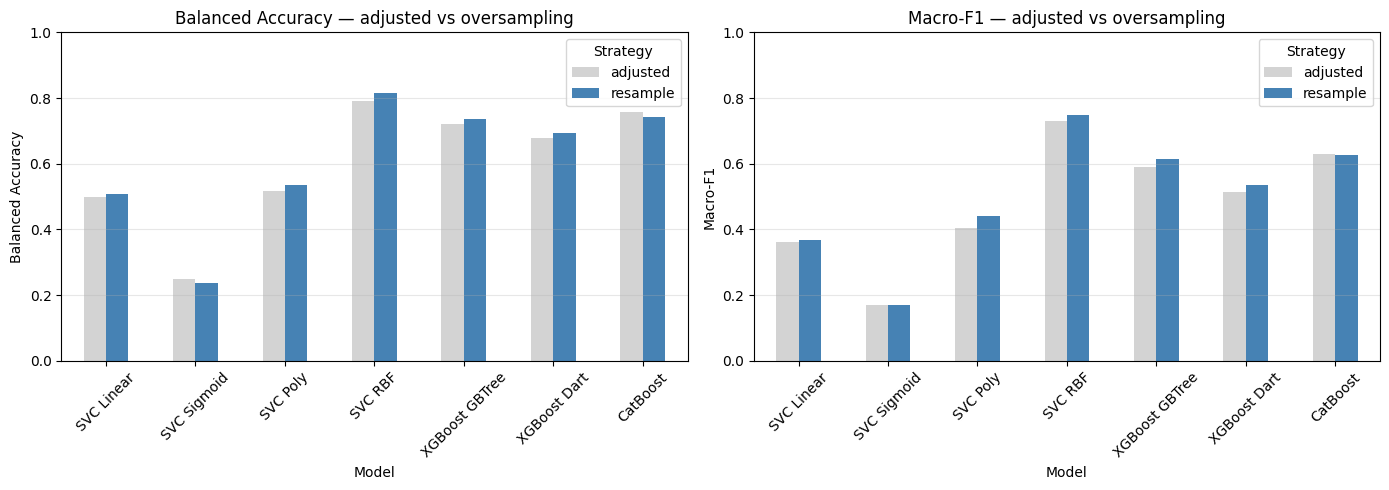

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric, title in zip(axes, ['balanced_accuracy', 'macro_f1'],
                             ['Balanced Accuracy', 'Macro-F1']):
    sub = res_df.pivot(index='Model', columns='Strategy', values=metric)
    sub = sub.reindex([m for m in MODELS if m in sub.index])
    sub = sub[[c for c in ['adjusted', 'resample'] if c in sub.columns]]
    sub.plot(kind='bar', ax=ax, color={'adjusted': 'lightgray', 'resample': 'steelblue'})
    ax.set_title(f'{title} — adjusted vs {STRATEGY}')
    ax.set_ylabel(title); ax.set_ylim(0, 1.0)
    ax.tick_params(axis='x', rotation=45); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, f'{STRATEGY}_bar_compare.png'), dpi=130, bbox_inches='tight')
plt.show()

## 8. Confusion Matrix Out-of-Fold (perhatikan kelas minoritas B)

Tiap baris = satu model; kiri = adjusted, kanan = resample. Prediksi out-of-fold mencerminkan generalisasi, bukan performa di data training.

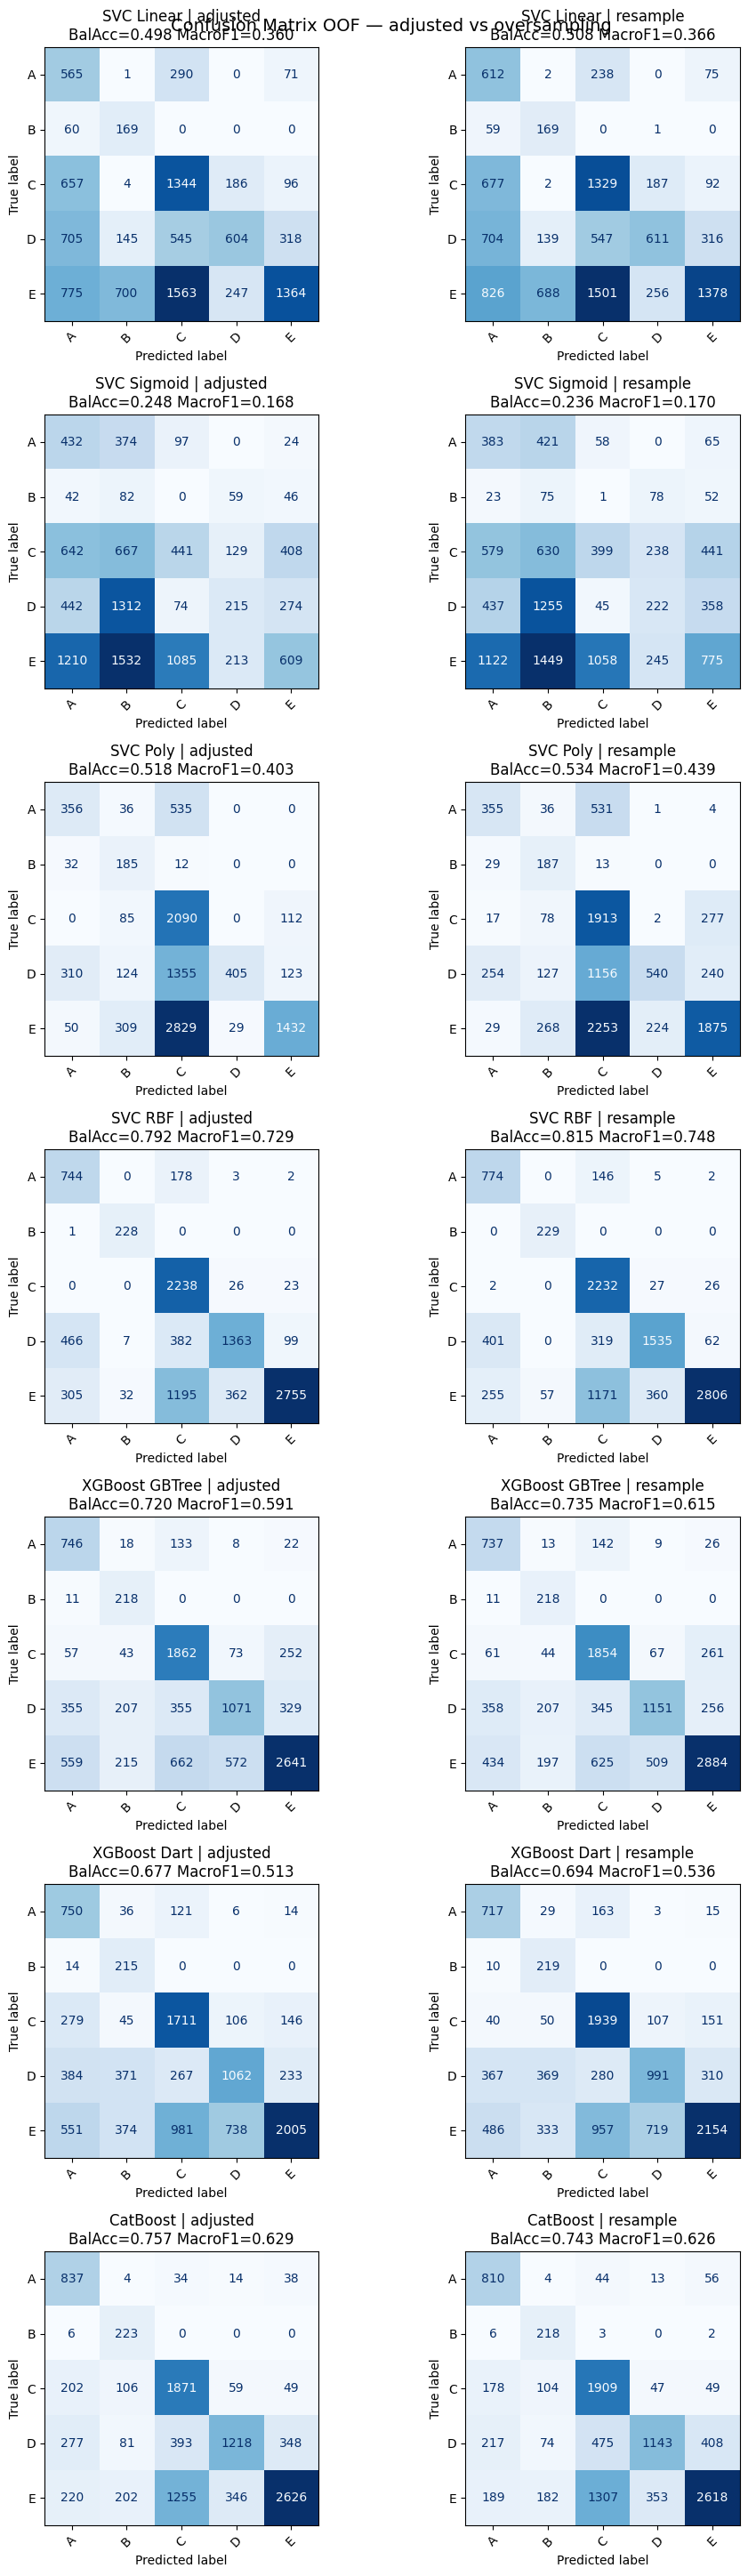

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

by_model = {}
for r in all_results:
    by_model.setdefault(r['model'], {})[r['mode']] = r
ordered = [m for m in MODELS if m in by_model]

nrows = len(ordered)
fig, axes = plt.subplots(nrows, 2, figsize=(10, 4.2 * nrows))
axes = np.atleast_2d(axes)
for i, name in enumerate(ordered):
    for j, mode in enumerate(['adjusted', 'resample']):
        ax = axes[i, j]
        r = by_model[name].get(mode)
        if r is None:
            ax.axis('off'); continue
        cm = confusion_matrix(r['y_true'], r['y_pred'], labels=labels)
        ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
            ax=ax, cmap='Blues', colorbar=False, values_format='d')
        ax.set_title(f"{name} | {mode}\nBalAcc={r['balanced_accuracy']:.3f} MacroF1={r['macro_f1']:.3f}")
        ax.tick_params(axis='x', rotation=45)
fig.suptitle(f'Confusion Matrix OOF — adjusted vs {STRATEGY}', fontsize=14)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, f'{STRATEGY}_confusion_matrices.png'), dpi=130, bbox_inches='tight')
plt.show()

In [16]:
# Classification report per kelas (fokus recall kelas minoritas B)
for name in ordered:
    for mode in ['adjusted', 'resample']:
        r = by_model[name].get(mode)
        if r is None: continue
        log('=' * 64)
        log(f'{name} | {mode}')
        log(classification_report(r['y_true'], r['y_pred'], labels=labels,
                                  target_names=class_names, zero_division=0))

SVC Linear | adjusted
              precision    recall  f1-score   support

           A       0.20      0.61      0.31       927
           B       0.17      0.74      0.27       229
           C       0.36      0.59      0.45      2287
           D       0.58      0.26      0.36      2317
           E       0.74      0.29      0.42      4649

    accuracy                           0.39     10409
   macro avg       0.41      0.50      0.36     10409
weighted avg       0.56      0.39      0.40     10409

SVC Linear | resample
              precision    recall  f1-score   support

           A       0.21      0.66      0.32       927
           B       0.17      0.74      0.28       229
           C       0.37      0.58      0.45      2287
           D       0.58      0.26      0.36      2317
           E       0.74      0.30      0.42      4649

    accuracy                           0.39     10409
   macro avg       0.41      0.51      0.37     10409
weighted avg       0.56      0.39

## 9. Learning Curve — cek Overfit / Underfit

Train vs validation **log loss** (`scoring='neg_log_loss'`, dibalik jadi positif) pada beberapa ukuran training set untuk tiap model dalam mode **resample** (`SMOTE(random_state=42, k_neighbors=5)` di fold training, classifier **tanpa** bobot kelas — sesuai keputusan: kalau sudah resampling, model tak perlu di-`balanced` lagi).

- Ambang verdict relatif terhadap log loss tebakan acak `ln(n_kelas)`: `gap = val − train` besar -> **overfit**; val tinggi (mendekati baseline) -> **underfit**; gap kecil & val rendah -> **well-fit**.
- CV & grup sama (`StratifiedKFold` by Sampling_ID); resampling hanya di subset training tiap fold -> tidak bocor.

> ℹ️ `probability=True` WAJIB: `neg_log_loss` butuh `predict_proba`. Tanpa ini SVC (yang default `probability=False`) menghasilkan skor NaN sehingga kurva SVC kosong. Konsekuensinya SVC pada oversampling jadi lambat (O(N²) + kalibrasi Platt).

In [17]:
from sklearn.model_selection import learning_curve, StratifiedKFold
from utils.imbalance_eval import make_resample_pipeline

LC_TRAIN_SIZES = np.linspace(0.2, 1.0, 5)   # 5 titik kurva
LC_CV          = 5
LC_SCORING     = 'neg_log_loss'  # pakai probabilitas untuk kurva learning curve
LC_STATE       = 42
groups_arr = np.asarray(groups)

lc_results = []
for name in MODELS:
    params = BEST_PARAMS[name]
    log(f'  > learning curve: {name} ...')
    try:
        pipe = make_resample_pipeline(name, params, RESAMPLER, n_optimal,
                                      xgb_device=XGB_DEVICE, cat_task_type=CAT_TASK_TYPE, probability=True)
        ts_abs, tr_sc, va_sc = learning_curve(
            pipe, X, y, groups=groups_arr,
            train_sizes=LC_TRAIN_SIZES,
            cv=StratifiedKFold(n_splits=LC_CV, shuffle=True, random_state=LC_STATE),
            scoring=LC_SCORING, n_jobs=1, shuffle=True, random_state=LC_STATE)
        lc_results.append({'model': name, 'train_sizes': ts_abs,
                           'train_mean': tr_sc.mean(1), 'train_std': tr_sc.std(1),
                           'val_mean': va_sc.mean(1), 'val_std': va_sc.std(1)})
    except Exception as e:
        log(f'    FAILED [{name}] -> {type(e).__name__}: {e}')
log(f'Learning curve selesai untuk {len(lc_results)} model.')

  > learning curve: SVC Linear ...
  > learning curve: SVC Sigmoid ...
  > learning curve: SVC Poly ...
  > learning curve: SVC RBF ...
  > learning curve: XGBoost GBTree ...
  > learning curve: XGBoost Dart ...
  > learning curve: CatBoost ...
Learning curve selesai untuk 7 model.


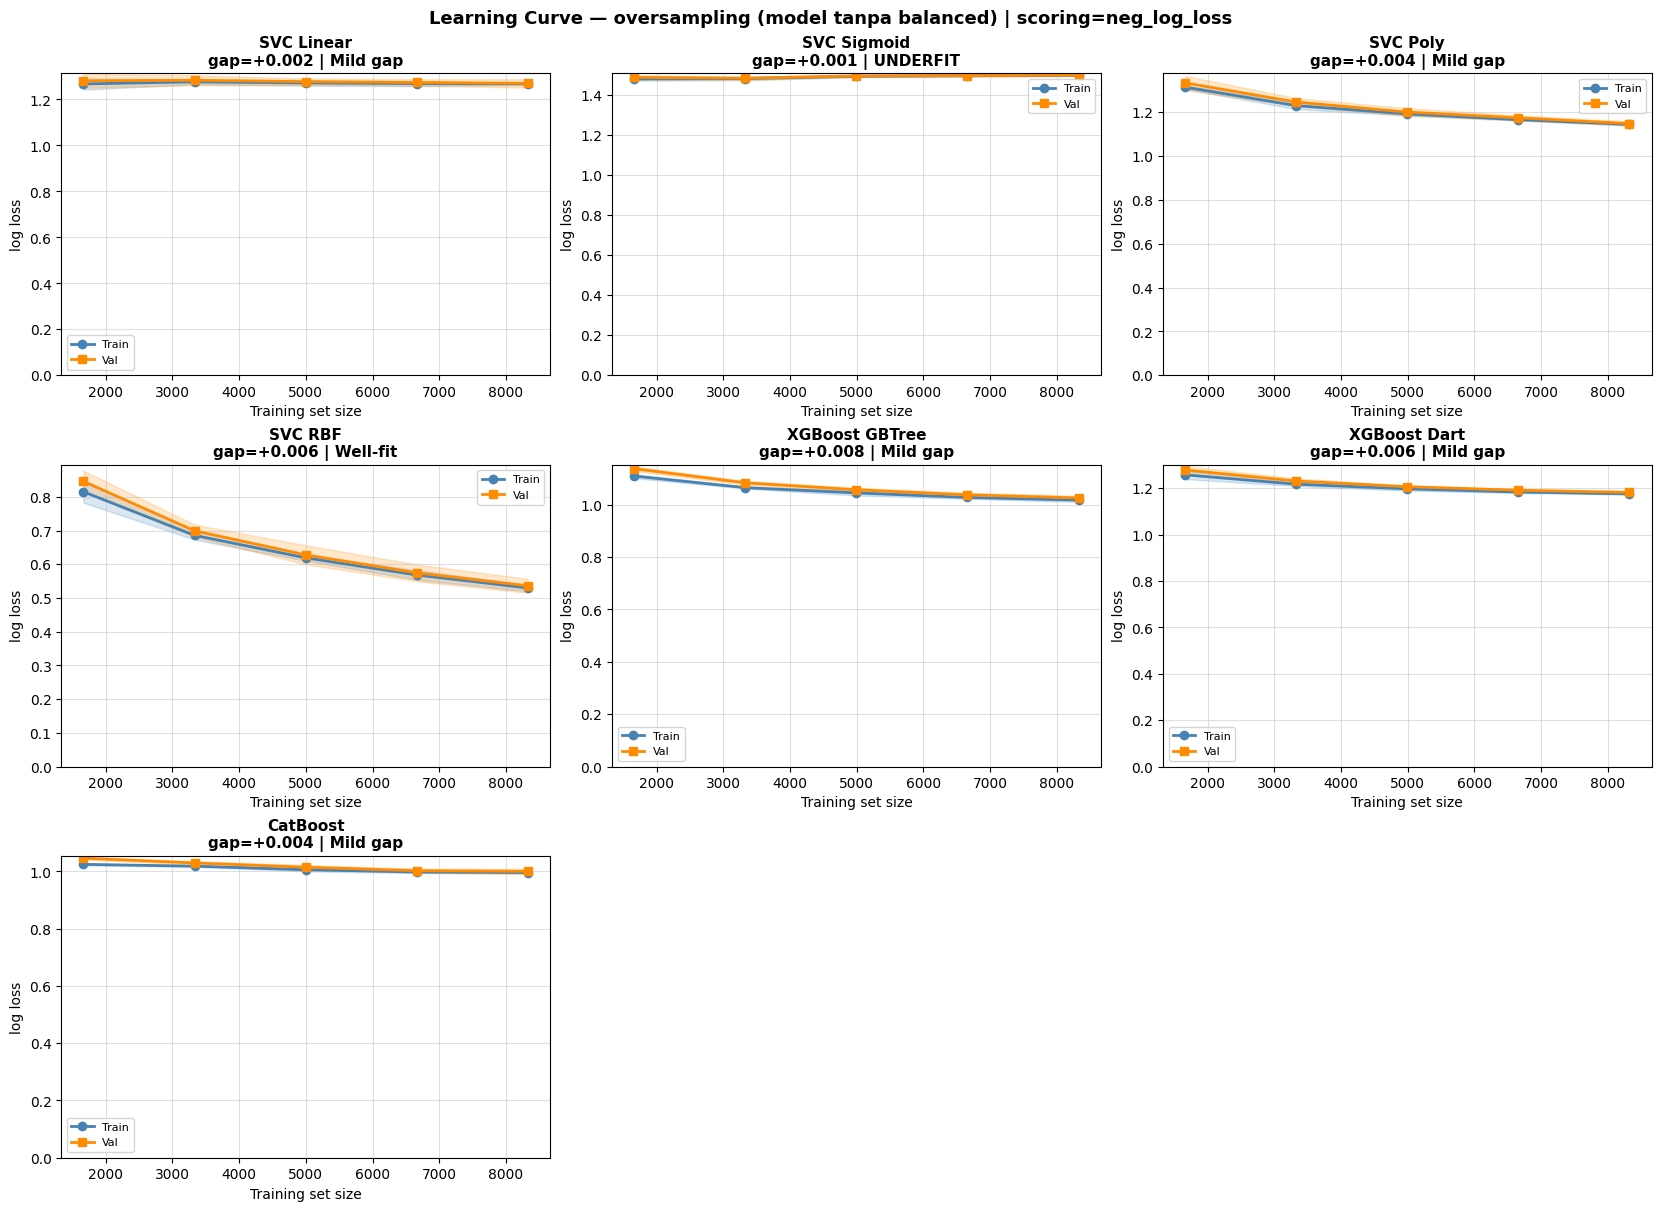


---- Ringkasan learning curve (training size terbesar, log loss) ----
Model                Train     Val     Gap
SVC RBF             0.5299  0.5362 +0.0062
CatBoost            0.9960  1.0000 +0.0040
XGBoost GBTree      1.0174  1.0259 +0.0085
SVC Poly            1.1437  1.1474 +0.0037
XGBoost Dart        1.1758  1.1821 +0.0064
SVC Linear          1.2677  1.2699 +0.0022
SVC Sigmoid         1.4991  1.5002 +0.0011


In [18]:
ncols = 3
nrows = (len(lc_results) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4 * nrows),
                         constrained_layout=True)
axes = np.array(axes).flatten()
LC_BASELINE = float(np.log(len(np.unique(y))))   # log loss tebakan-acak (ambang verdict)
for ax, r in zip(axes, lc_results):
    ts = r['train_sizes']
    trm, vam = -r['train_mean'], -r['val_mean']   # neg_log_loss → log loss (positif; makin kecil makin baik)
    trs, vas = r['train_std'], r['val_std']
    ax.plot(ts, trm, 'o-', color='steelblue', lw=2, label='Train')
    ax.fill_between(ts, trm - trs, trm + trs, alpha=0.2, color='steelblue')
    ax.plot(ts, vam, 's-', color='darkorange', lw=2, label='Val')
    ax.fill_between(ts, vam - vas, vam + vas, alpha=0.2, color='darkorange')
    gap = vam[-1] - trm[-1]   # val_loss − train_loss (>0 → overfit)
    verdict = ('OVERFIT' if gap > 0.15 * LC_BASELINE
               else 'UNDERFIT' if vam[-1] > 0.80 * LC_BASELINE
               else 'Well-fit' if gap < 0.05 * LC_BASELINE and vam[-1] < 0.40 * LC_BASELINE
               else 'Mild gap')
    ax.set_title(f"{r['model']}\ngap={gap:+.3f} | {verdict}", fontsize=11, fontweight='bold')
    ax.set_xlabel('Training set size'); ax.set_ylabel('log loss')
    ax.set_ylim(bottom=0); ax.grid(True, alpha=0.4); ax.legend(fontsize=8)
for ax in axes[len(lc_results):]:
    ax.set_visible(False)
fig.suptitle(f'Learning Curve — {STRATEGY} (model tanpa balanced) | scoring={LC_SCORING}',
             fontsize=13, fontweight='bold')
fig.savefig(os.path.join(OUT_DIR, f'{STRATEGY}_learning_curve.png'), dpi=120, bbox_inches='tight')
plt.show()

log('\n---- Ringkasan learning curve (training size terbesar, log loss) ----')
log(f"{'Model':<18s}{'Train':>8s}{'Val':>8s}{'Gap':>8s}")
for r in sorted(lc_results, key=lambda x: -x['val_mean'][-1]):
    trl, val = -r['train_mean'][-1], -r['val_mean'][-1]
    log(f"{r['model']:<18s}{trl:>8.4f}{val:>8.4f}{val - trl:>+8.4f}")

## 10. Kurva Seluruh Metrik Evaluasi (Train vs Val)

Learning curve untuk **semua** metrik sekaligus: **accuracy, precision, recall, f1 (macro)** dan **loss function (log loss)** terhadap ukuran data latih. Tiap (ukuran fold) di-*fit* sekali lalu kelima metrik dihitung bersama (lebih hemat daripada memanggil `learning_curve` per-metrik). Lingkup = mode **resample** (`SMOTE(random_state=42, k_neighbors=5)` di fold training, classifier tanpa bobot), sama dengan Sel 9. Grid: satu panel per model.

In [19]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, log_loss)

# Pakai konfigurasi yg sama dgn Sel 9 (LC_TRAIN_SIZES, LC_CV, LC_STATE).
CURVE_METRICS = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'log_loss']

def _full_proba(pipe, Xset, labels):
    """Selaraskan kolom predict_proba ke urutan `labels` (isi 0 utk kelas yg tak
    dilatih di subset), lalu normalisasi -> aman utk log_loss & subset kecil."""
    proba = np.asarray(pipe.predict_proba(Xset), dtype=float)
    idx = {c: k for k, c in enumerate(labels)}
    full = np.zeros((proba.shape[0], len(labels)))
    for k, c in enumerate(pipe.classes_):
        full[:, idx[c]] = proba[:, k]
    s = full.sum(1, keepdims=True); s[s == 0] = 1.0
    return full / s

def _score_all(y_true, y_pred, y_proba, labels):
    return {
        'accuracy':        accuracy_score(y_true, y_pred),
        'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro':    recall_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_macro':        f1_score(y_true, y_pred, average='macro', zero_division=0),
        'log_loss':        log_loss(y_true, y_proba, labels=labels),
    }

curves = {}   # model -> metric -> (sizes, tr_mean, tr_std, va_mean, va_std)
skf_cv = StratifiedKFold(LC_CV, shuffle=True, random_state=LC_STATE)
nsz = len(LC_TRAIN_SIZES); min_n = len(np.unique(y))
for name in MODELS:
    log(f'  > Kurva metrik: {name} ...')
    tr = {m: [[] for _ in range(nsz)] for m in CURVE_METRICS}
    va = {m: [[] for _ in range(nsz)] for m in CURVE_METRICS}
    for tr_idx, va_idx in skf_cv.split(X, y):
        tr_idx = tr_idx.copy()
        np.random.RandomState(LC_STATE).shuffle(tr_idx)
        Xva, yva = X.iloc[va_idx], y[va_idx]
        for k, frac in enumerate(LC_TRAIN_SIZES):
            sub = tr_idx[:max(min_n, int(round(frac * len(tr_idx))))]
            Xsub, ysub = X.iloc[sub], y[sub]
            try:
                pipe = make_resample_pipeline(
                    name, BEST_PARAMS[name], RESAMPLER, n_optimal,
                    xgb_device=XGB_DEVICE, cat_task_type=CAT_TASK_TYPE, probability=True)
                pipe.fit(Xsub, ysub)
                for Xset, yset, store in ((Xsub, ysub, tr), (Xva, yva, va)):
                    yp = np.ravel(pipe.predict(Xset))
                    sc = _score_all(yset, yp, _full_proba(pipe, Xset, labels), labels)
                    for m in CURVE_METRICS:
                        store[m][k].append(sc[m])
            except Exception as e:
                for m in CURVE_METRICS:
                    tr[m][k].append(np.nan); va[m][k].append(np.nan)
                log(f'    skip [{name}|frac={frac:.2f}] -> {type(e).__name__}: {e}')
    curves[name] = {
        m: (LC_TRAIN_SIZES,
            np.array([np.nanmean(tr[m][k]) for k in range(nsz)]),
            np.array([np.nanstd(tr[m][k])  for k in range(nsz)]),
            np.array([np.nanmean(va[m][k]) for k in range(nsz)]),
            np.array([np.nanstd(va[m][k])  for k in range(nsz)]))
        for m in CURVE_METRICS}
log(f'Kurva metrik selesai: {len(curves)} model.')

  > Kurva metrik: SVC Linear ...
  > Kurva metrik: SVC Sigmoid ...
  > Kurva metrik: SVC Poly ...
  > Kurva metrik: SVC RBF ...
  > Kurva metrik: XGBoost GBTree ...
  > Kurva metrik: XGBoost Dart ...
  > Kurva metrik: CatBoost ...
Kurva metrik selesai: 7 model.


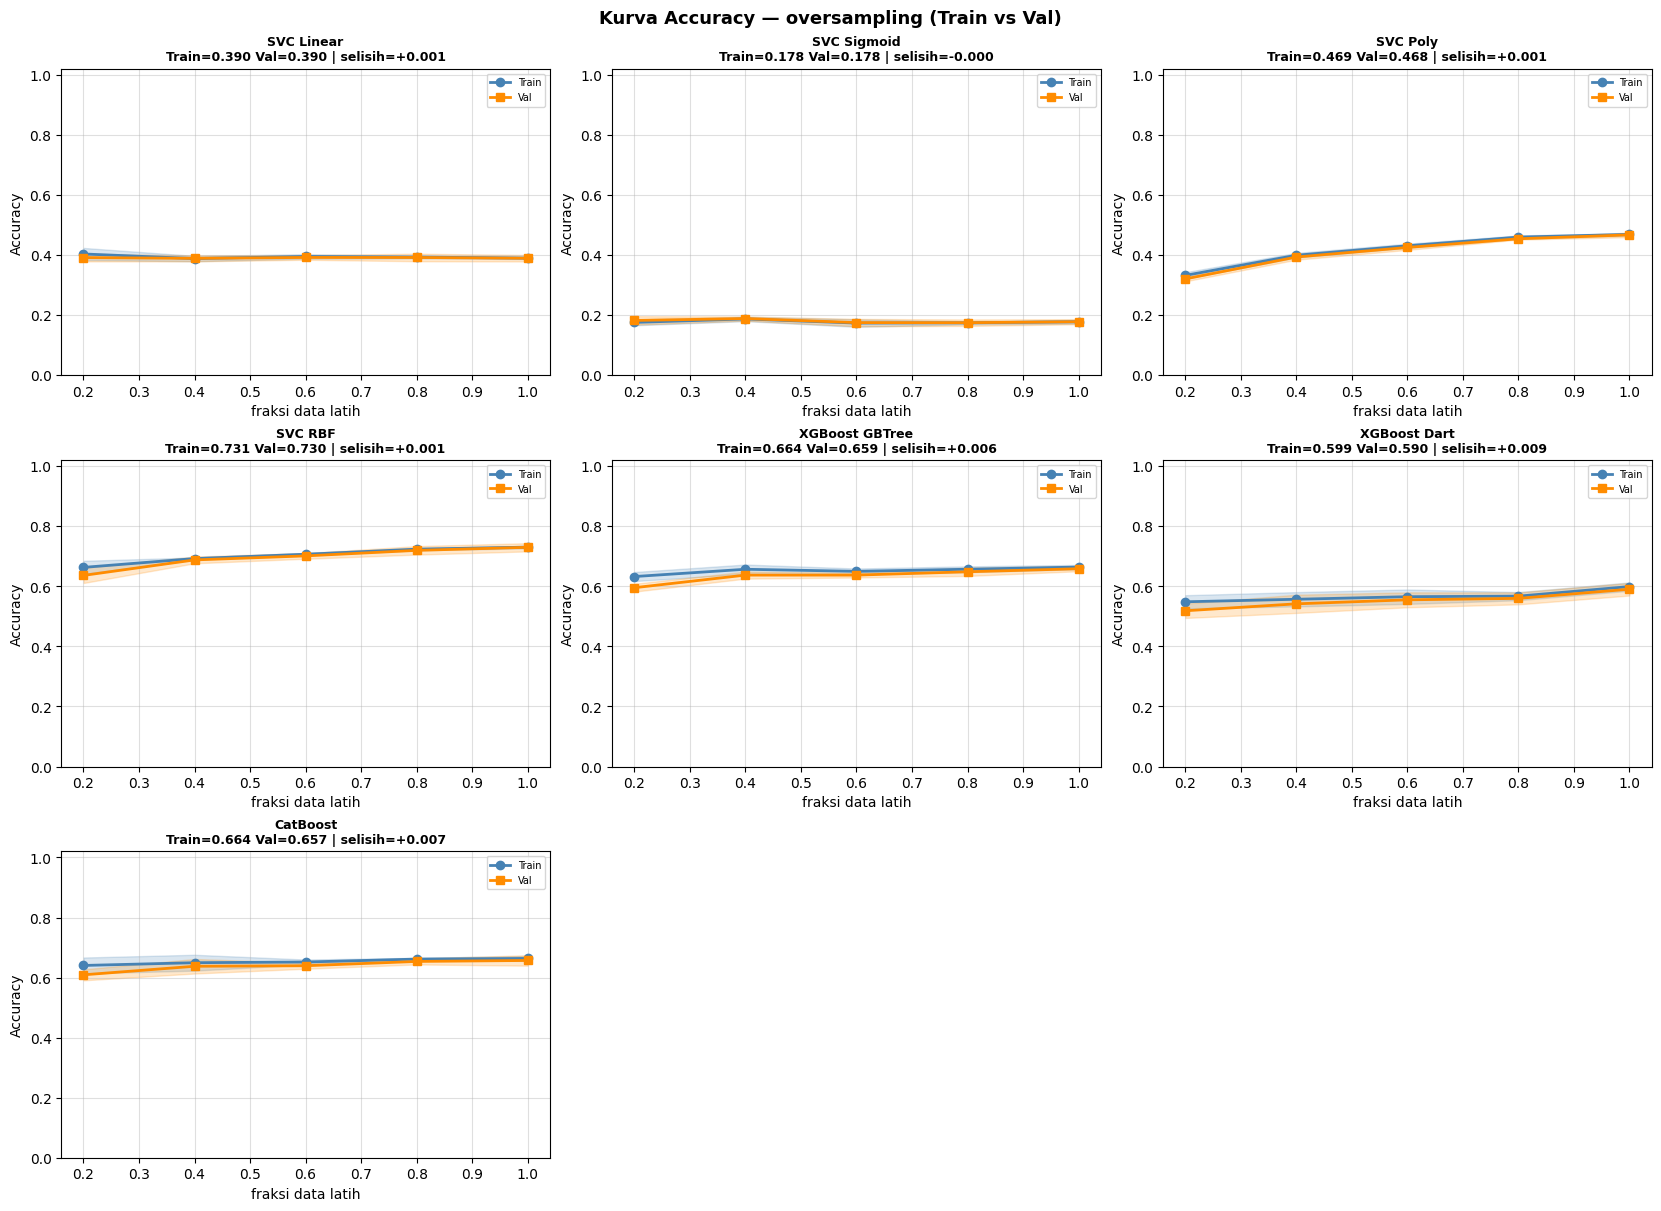

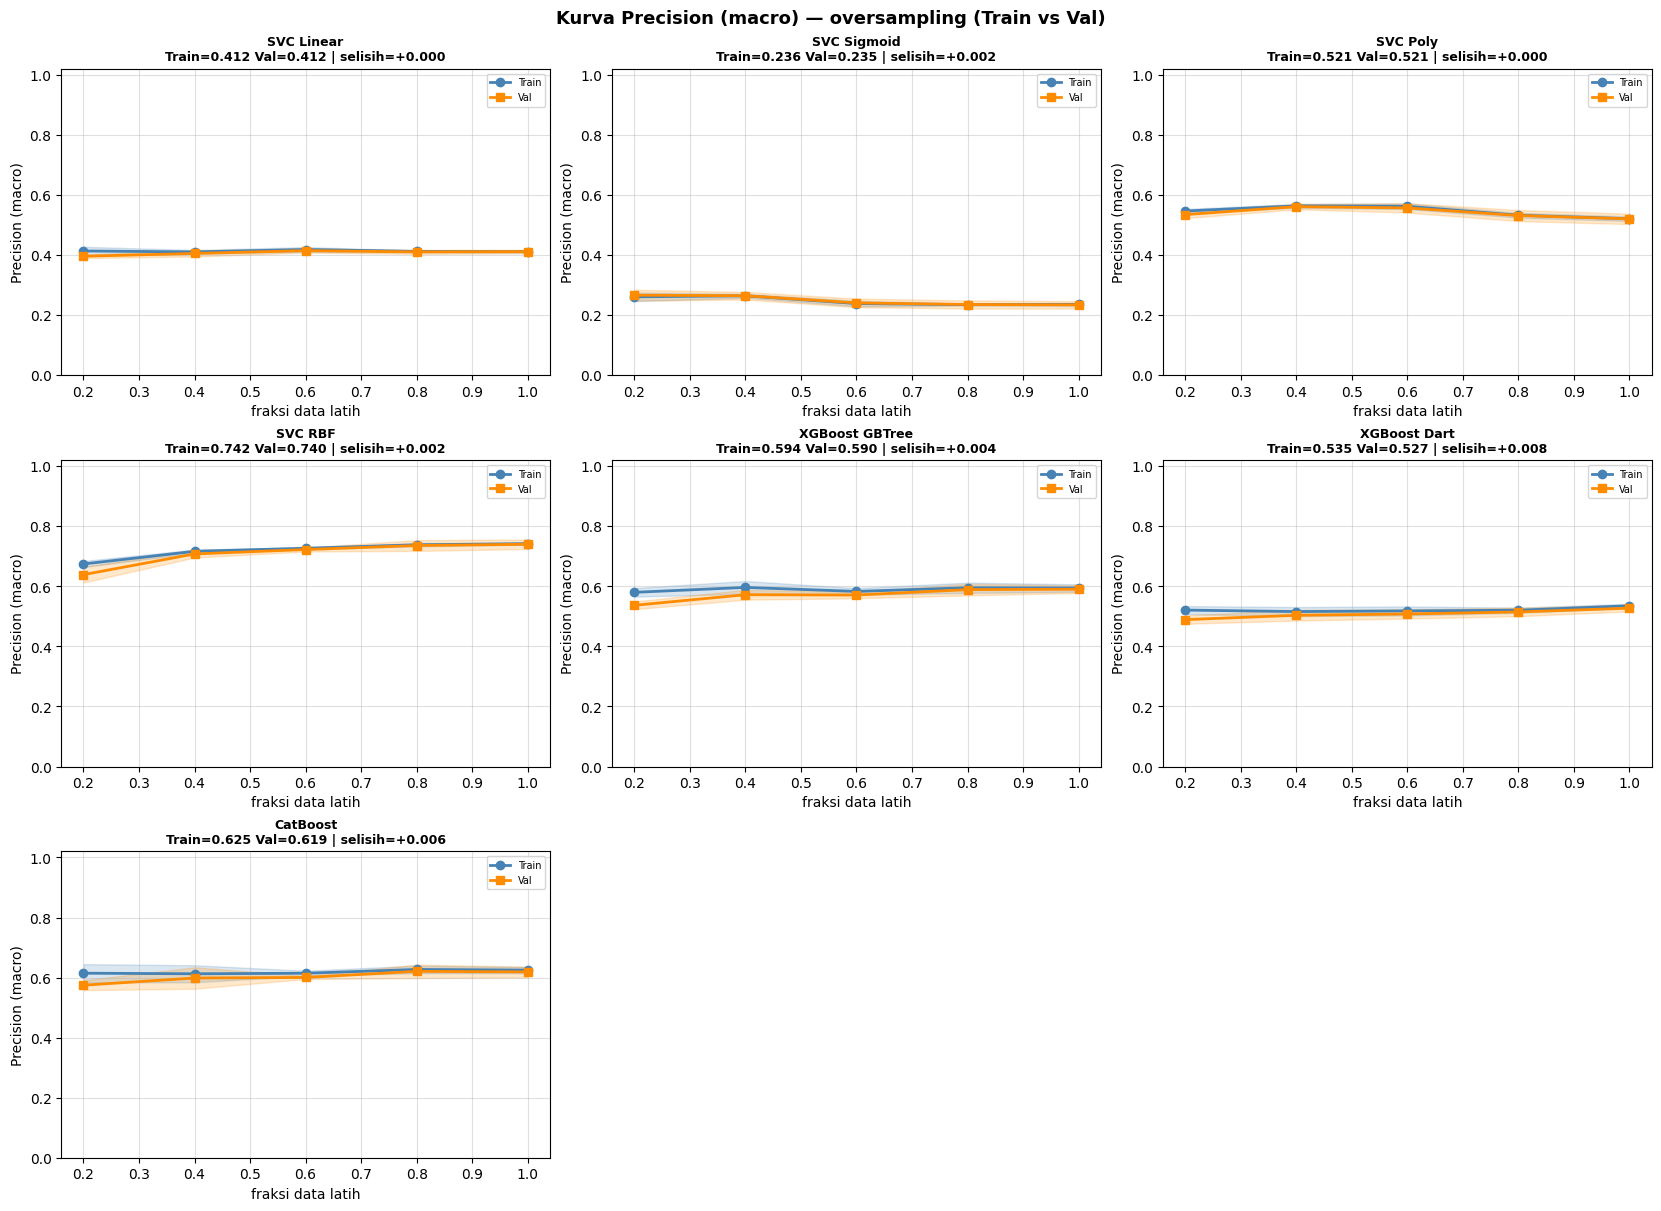

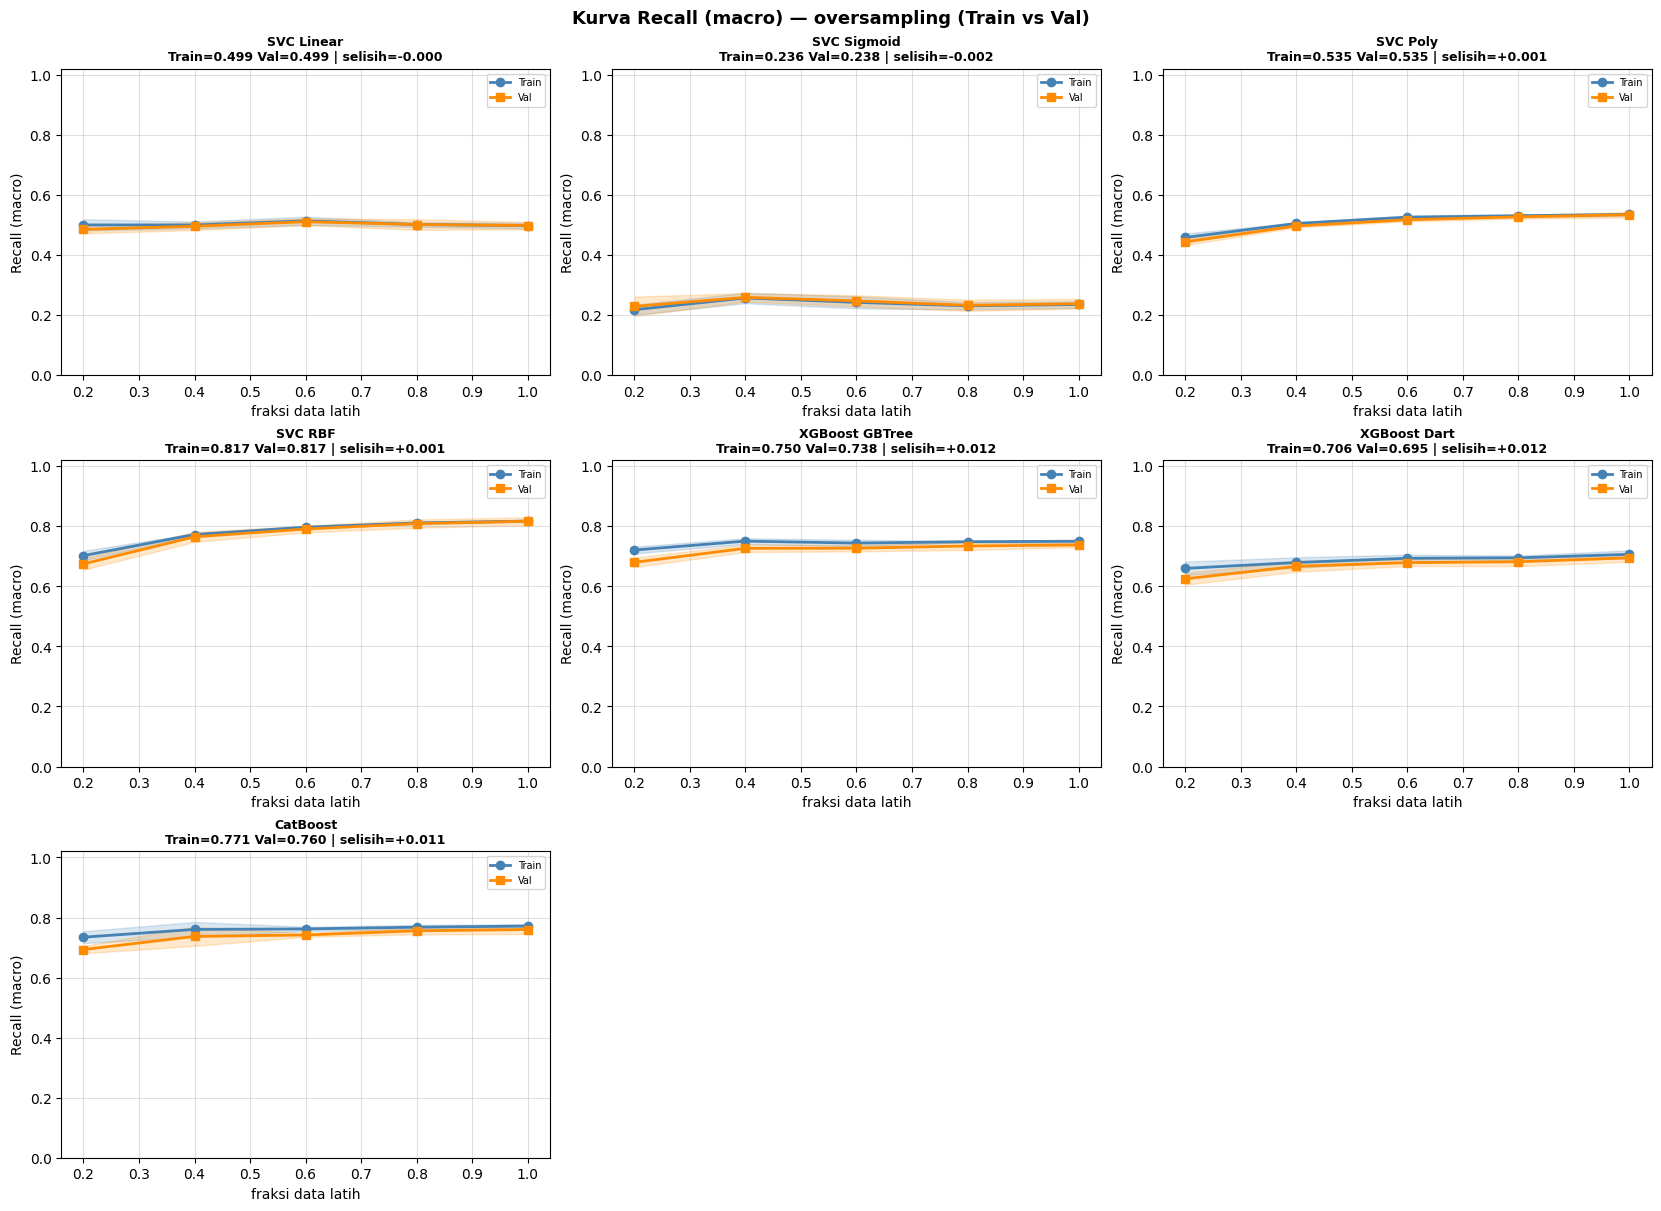

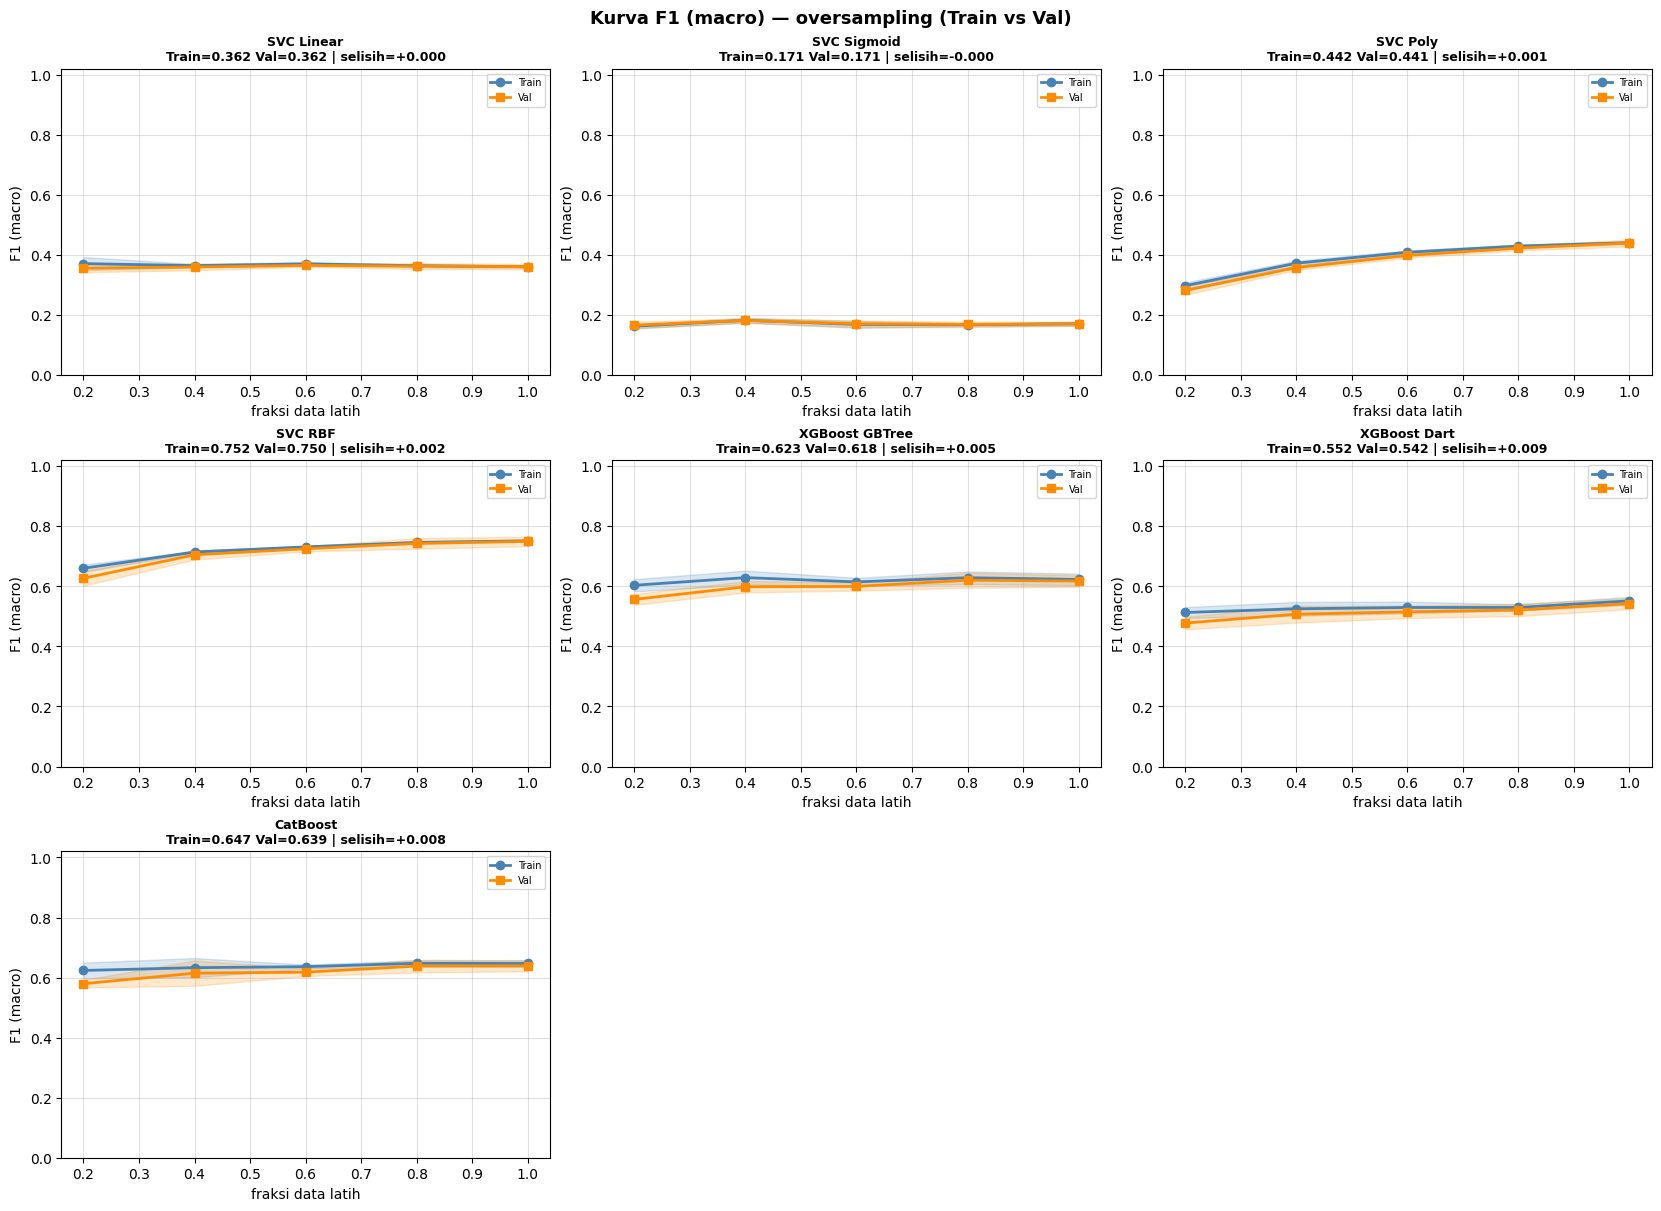

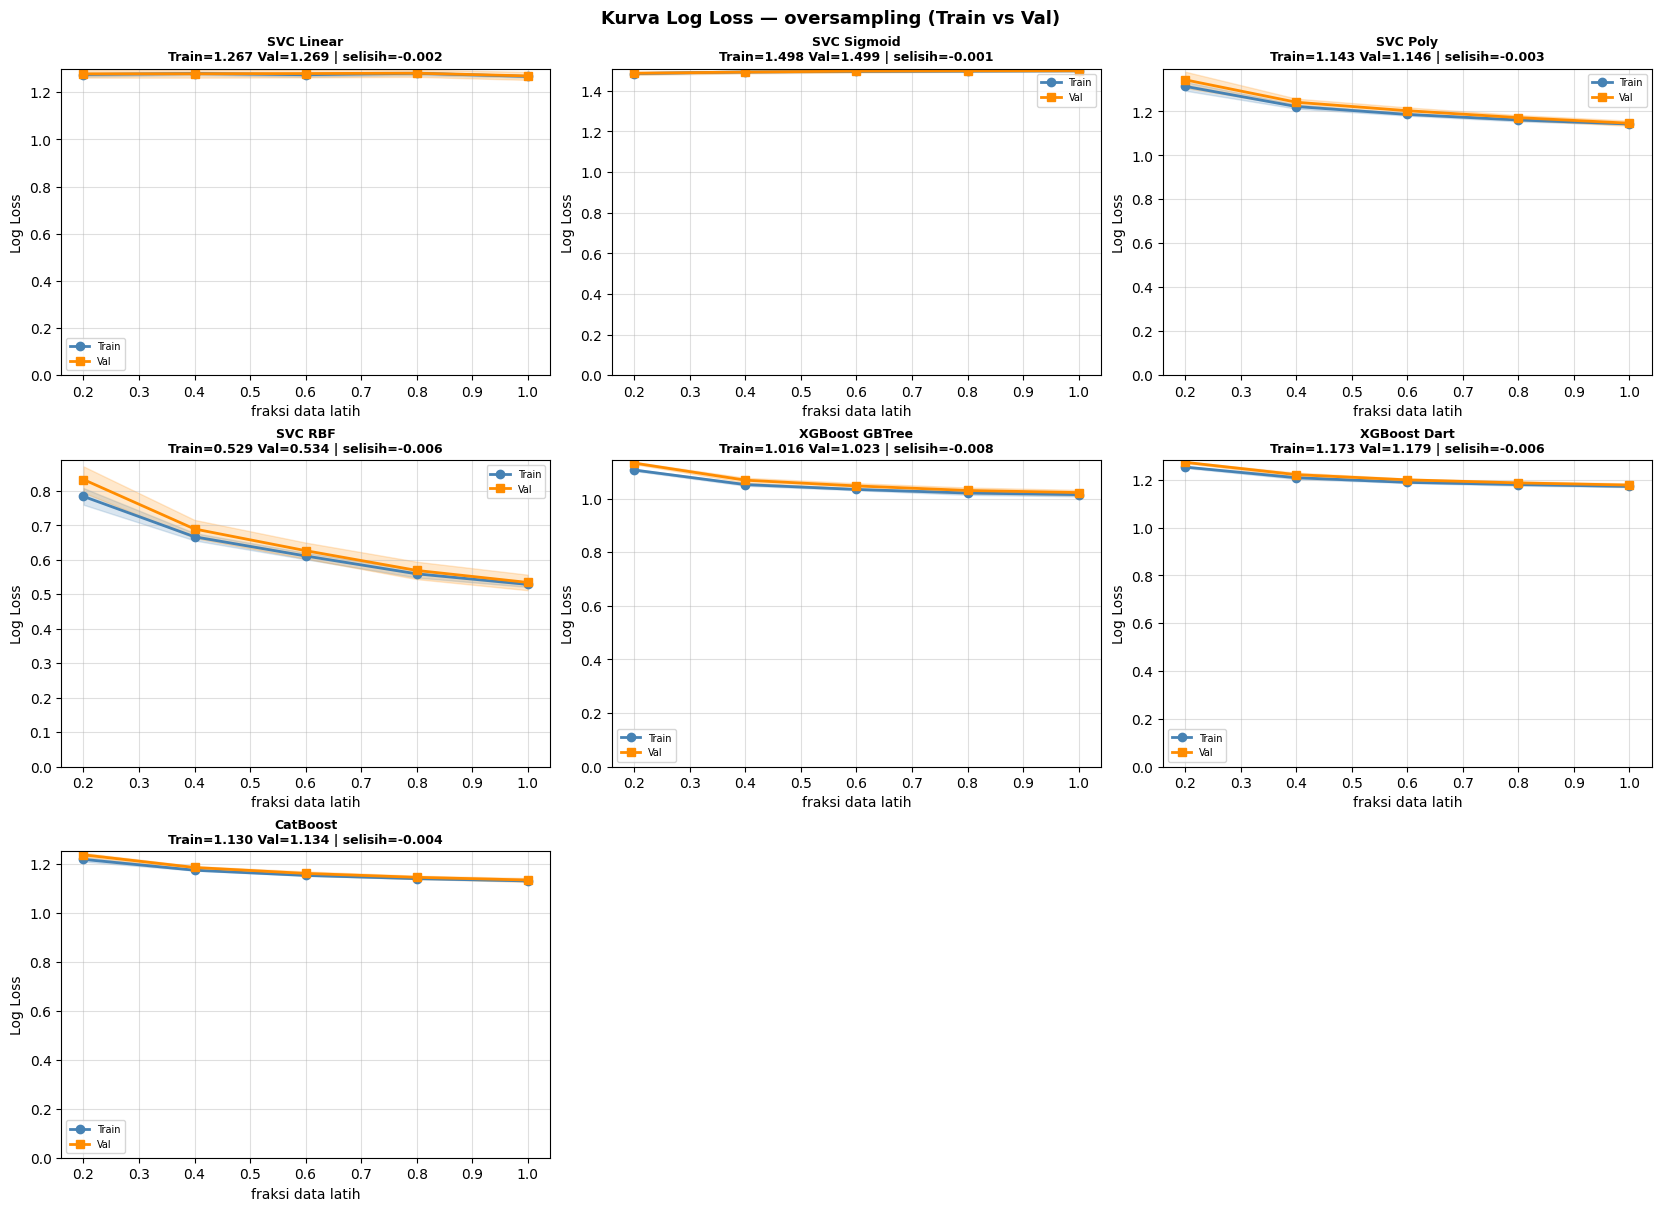

In [20]:
METRIC_TITLES = {'accuracy': 'Accuracy', 'precision_macro': 'Precision (macro)',
                 'recall_macro': 'Recall (macro)', 'f1_macro': 'F1 (macro)',
                 'log_loss': 'Log Loss'}
ncols = 3
nrows = (len(MODELS) + ncols - 1) // ncols
for metric in CURVE_METRICS:
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4 * nrows),
                             constrained_layout=True)
    axes = np.array(axes).flatten()
    for ax, name in zip(axes, MODELS):
        if name not in curves:
            ax.axis('off'); continue
        ts, trm, trs, vam, vas = curves[name][metric]
        ax.plot(ts, trm, 'o-', color='steelblue', lw=2, label='Train')
        ax.fill_between(ts, trm - trs, trm + trs, alpha=0.2, color='steelblue')
        ax.plot(ts, vam, 's-', color='darkorange', lw=2, label='Val')
        ax.fill_between(ts, vam - vas, vam + vas, alpha=0.2, color='darkorange')
        # selisih train vs val di fraksi data latih terbesar
        gap = trm[-1] - vam[-1]
        ax.set_title(f'{name}\nTrain={trm[-1]:.3f} Val={vam[-1]:.3f} | selisih={gap:+.3f}',
                     fontsize=9, fontweight='bold')
        ax.set_xlabel('fraksi data latih'); ax.set_ylabel(METRIC_TITLES[metric])
        if metric == 'log_loss':
            ax.set_ylim(bottom=0)
        else:
            ax.set_ylim(0, 1.02)
        ax.grid(True, alpha=0.4); ax.legend(fontsize=7)
    for ax in axes[len(MODELS):]:
        ax.set_visible(False)
    fig.suptitle(f'Kurva {METRIC_TITLES[metric]} — {STRATEGY} (Train vs Val)',
                 fontsize=13, fontweight='bold')
    fig.savefig(os.path.join(OUT_DIR, f'{STRATEGY}_curve_{metric}.png'),
                dpi=110, bbox_inches='tight')
    plt.show()

### Selisih (gap) Train vs Val — tabel terpisah per metrik

Satu tabel untuk tiap metrik (**Accuracy, Precision, Recall, F1**, dan Log Loss), berisi nilai `Train`, `Val`, dan `Selisih (Train-Val)` di fraksi data latih terbesar untuk tiap model (mode `resample` SMOTE). Kolom `overfit_gap` menyeragamkan arah: **>0 = indikasi overfit** (skor = Train−Val; `log_loss` = Val−Train, karena loss makin kecil makin baik). Makin besar `overfit_gap`, makin lebar jurang train↔val.

In [21]:
# -- Tabel selisih (gap) Train vs Val, DIPISAH per metrik (fraksi data latih terbesar) --
gap_tables = {}
for metric in CURVE_METRICS:
    rows = []
    for name, mdict in curves.items():
        ts, trm, trs, vam, vas = mdict[metric]
        train_f, val_f = float(trm[-1]), float(vam[-1])
        train_s, val_s = float(trs[-1]), float(vas[-1])   # std antar-fold di fraksi terbesar
        selisih = train_f - val_f
        overfit_gap = (val_f - train_f) if metric == 'log_loss' else (train_f - val_f)
        rows.append({'Model': name,
                     'Train': train_f, 'Train_std': train_s,
                     'Val': val_f, 'Val_std': val_s,
                     'Selisih (Train-Val)': selisih, 'overfit_gap': overfit_gap})
    df = pd.DataFrame(rows)
    gap_tables[metric] = df
    df.to_csv(os.path.join(OUT_DIR, f'{STRATEGY}_gap_{metric}.csv'), index=False)
    log(f'[{METRIC_TITLES[metric]}] selisih train-val -> {STRATEGY}_gap_{metric}.csv')

# Tampilkan satu tabel per metrik: Train & Val sbg 'mean ± std' (overfit_gap diwarnai).
for metric in CURVE_METRICS:
    df = gap_tables[metric]
    disp = pd.DataFrame({'Model': df['Model']})
    disp['Train'] = [f'{m:.4f} ± {s:.4f}' for m, s in zip(df['Train'], df['Train_std'])]
    disp['Val']   = [f'{m:.4f} ± {s:.4f}' for m, s in zip(df['Val'], df['Val_std'])]
    disp['Selisih (Train-Val)'] = df['Selisih (Train-Val)']
    disp['overfit_gap'] = df['overfit_gap']
    print('=' * 60)
    print(f'Metrik: {METRIC_TITLES[metric]}')
    display(disp.style.format({'Selisih (Train-Val)': '{:.4f}', 'overfit_gap': '{:.4f}'})
            .background_gradient(cmap='Reds', subset=['overfit_gap']))

[Accuracy] selisih train-val -> oversampling_gap_accuracy.csv
[Precision (macro)] selisih train-val -> oversampling_gap_precision_macro.csv
[Recall (macro)] selisih train-val -> oversampling_gap_recall_macro.csv
[F1 (macro)] selisih train-val -> oversampling_gap_f1_macro.csv
[Log Loss] selisih train-val -> oversampling_gap_log_loss.csv
Metrik: Accuracy


,Model,Train,Val,Selisih (Train-Val),overfit_gap
0,SVC Linear,0.3903 ± 0.0032,0.3898 ± 0.0107,0.0006,0.0006
1,SVC Sigmoid,0.1783 ± 0.0062,0.1784 ± 0.0085,-0.0001,-0.0001
2,SVC Poly,0.4691 ± 0.0039,0.4677 ± 0.0077,0.0015,0.0015
3,SVC RBF,0.7306 ± 0.0040,0.7300 ± 0.0137,0.0005,0.0005
4,XGBoost GBTree,0.6642 ± 0.0071,0.6587 ± 0.0084,0.0055,0.0055
5,XGBoost Dart,0.5991 ± 0.0138,0.5904 ± 0.0210,0.0087,0.0087
6,CatBoost,0.6636 ± 0.0082,0.6569 ± 0.0174,0.0067,0.0067


Metrik: Precision (macro)


,Model,Train,Val,Selisih (Train-Val),overfit_gap
0,SVC Linear,0.4120 ± 0.0039,0.4119 ± 0.0059,0.0000,0.0000
1,SVC Sigmoid,0.2361 ± 0.0051,0.2345 ± 0.0123,0.0016,0.0016
2,SVC Poly,0.5213 ± 0.0076,0.5209 ± 0.0174,0.0004,0.0004
3,SVC RBF,0.7422 ± 0.0032,0.7401 ± 0.0159,0.0021,0.0021
4,XGBoost GBTree,0.5942 ± 0.0125,0.5904 ± 0.0126,0.0038,0.0038
5,XGBoost Dart,0.5352 ± 0.0069,0.5273 ± 0.0108,0.0080,0.0080
6,CatBoost,0.6249 ± 0.0105,0.6188 ± 0.0176,0.0061,0.0061


Metrik: Recall (macro)


,Model,Train,Val,Selisih (Train-Val),overfit_gap
0,SVC Linear,0.4986 ± 0.0093,0.4987 ± 0.0119,-0.0001,-0.0001
1,SVC Sigmoid,0.2358 ± 0.0110,0.2382 ± 0.0162,-0.0024,-0.0024
2,SVC Poly,0.5355 ± 0.0040,0.5347 ± 0.0094,0.0008,0.0008
3,SVC RBF,0.8174 ± 0.0035,0.8168 ± 0.0130,0.0006,0.0006
4,XGBoost GBTree,0.7501 ± 0.0054,0.7377 ± 0.0071,0.0124,0.0124
5,XGBoost Dart,0.7065 ± 0.0134,0.6949 ± 0.0131,0.0116,0.0116
6,CatBoost,0.7714 ± 0.0069,0.7599 ± 0.0153,0.0114,0.0114


Metrik: F1 (macro)


,Model,Train,Val,Selisih (Train-Val),overfit_gap
0,SVC Linear,0.3617 ± 0.0040,0.3616 ± 0.0092,0.0000,0.0000
1,SVC Sigmoid,0.1714 ± 0.0065,0.1715 ± 0.0068,-0.0001,-0.0001
2,SVC Poly,0.4417 ± 0.0050,0.4406 ± 0.0115,0.0011,0.0011
3,SVC RBF,0.7517 ± 0.0031,0.7498 ± 0.0159,0.0019,0.0019
4,XGBoost GBTree,0.6230 ± 0.0195,0.6176 ± 0.0192,0.0054,0.0054
5,XGBoost Dart,0.5516 ± 0.0133,0.5424 ± 0.0184,0.0092,0.0092
6,CatBoost,0.6469 ± 0.0114,0.6390 ± 0.0179,0.0079,0.0079


Metrik: Log Loss


,Model,Train,Val,Selisih (Train-Val),overfit_gap
0,SVC Linear,1.2669 ± 0.0046,1.2689 ± 0.0168,-0.0020,0.0020
1,SVC Sigmoid,1.4982 ± 0.0032,1.4995 ± 0.0062,-0.0013,0.0013
2,SVC Poly,1.1426 ± 0.0032,1.1460 ± 0.0120,-0.0034,0.0034
3,SVC RBF,0.5287 ± 0.0074,0.5343 ± 0.0226,-0.0057,0.0057
4,XGBoost GBTree,1.0155 ± 0.0066,1.0231 ± 0.0100,-0.0076,0.0076
5,XGBoost Dart,1.1729 ± 0.0030,1.1787 ± 0.0068,-0.0057,0.0057
6,CatBoost,1.1300 ± 0.0023,1.1335 ± 0.0081,-0.0036,0.0036


## 11. Kesimpulan

Bandingkan kolom **Delta** di tabel berpasangan (sel 6) dan recall kelas **B** di confusion matrix:

- Delta `balanced_accuracy`/`macro_f1` **positif** -> resampling (`oversampling`) mengungguli adjusted model untuk model tsb.
- Perhatikan trade-off: resampling kadang menaikkan recall minoritas tapi menurunkan precision / accuracy keseluruhan.
- **Learning curve (sel 9)** menunjukkan overfit/underfit tiap model di mode resampling (tanpa balanced). Gap train-val besar -> overfit; val rendah -> underfit.
- **Kurva seluruh metrik (sel 10)**: accuracy, precision, recall, F1 (macro), dan log loss Train vs Val terhadap ukuran data latih untuk tiap model, plus tabel selisih (gap) per metrik (`overfit_gap` > 0 = indikasi overfit).
- Semua angka dari `StratifiedKFold(Sampling_ID)` + resampling khusus fold training, jadi sudah bebas kebocoran antar-sampel.

File hasil tersimpan di `OUT_DIR` (CSV metrik, paired delta, gap per metrik, PNG bar/CM/learning curve/kurva metrik).